# Sentiment Analysis for Retrieved X Posts
Use VADER sentiment (NLTK) to score each post from -1 (negative) to 1 (positive), without PyTorch.

In [1]:
import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

CSV_PATH = "recent_tweets_elon_gavin.csv"

nltk.download("vader_lexicon", quiet=True)

df = pd.read_csv(CSV_PATH)
df = df.copy()
df[["id", "username", "text"]].head()

FileNotFoundError: [Errno 2] No such file or directory: 'recent_tweets_elon_gavin.csv'

In [ ]:
sia = SentimentIntensityAnalyzer()


In [2]:
def score_to_minus1_plus1(text: str) -> float:
    text = "" if pd.isna(text) else str(text)
    sentiment = sia.polarity_scores(text)["compound"]
    if sentiment > 1.0:
        sentiment = 1.0
    elif sentiment < -1.0:
        sentiment = -1.0
    return float(sentiment)

df["sentiment_score"] = df["text"].apply(score_to_minus1_plus1)

df["sentiment_label"] = pd.cut(
    df["sentiment_score"],
    bins=[-1.0001, -0.2, 0.2, 1.0001],
    labels=["negative", "neutral", "positive"],
)

df[["username", "text", "sentiment_score", "sentiment_label"]].head(10)

NameError: name 'df' is not defined

## RoBERTa

In [3]:
import sys
import subprocess
import numpy as np
import pandas as pd
import nltk
from scipy.special import softmax
from scipy.stats import pearsonr, spearmanr
from nltk.sentiment import SentimentIntensityAnalyzer

# Ensure transformer dependencies are available in the notebook kernel
for pkg in ["transformers", "torch"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

from transformers import AutoTokenizer, AutoModelForSequenceClassification

CSV_PATH = "recent_posts_2503.csv"
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"

# Load data
comp_df = pd.read_csv(CSV_PATH).copy()
comp_df = comp_df.dropna(subset=["text"]).copy()
comp_df["text"] = comp_df["text"].astype(str)

# -------- VADER --------
nltk.download("vader_lexicon", quiet=True)
sia = SentimentIntensityAnalyzer()

def vader_label(score: float) -> str:
    if score <= -0.2:
        return "negative"
    if score >= 0.2:
        return "positive"
    return "neutral"

comp_df["vader_score"] = comp_df["text"].apply(lambda t: float(sia.polarity_scores(t)["compound"]))
comp_df["vader_label"] = comp_df["vader_score"].apply(vader_label)

# -------- RoBERTa --------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

def normalize_label(label: str) -> str:
    label = str(label).lower()
    if "neg" in label:
        return "negative"
    if "neu" in label:
        return "neutral"
    return "positive"

id2label = {int(k): normalize_label(v) for k, v in model.config.id2label.items()}
weights = np.array([{"negative": -1.0, "neutral": 0.0, "positive": 1.0}[id2label[i]] for i in range(len(id2label))])

def roberta_sentiment(text: str):
    encoded = tokenizer(text, truncation=True, max_length=512, return_tensors="pt")
    logits = model(**encoded).logits.detach().numpy()[0]
    probs = softmax(logits)
    label_idx = int(np.argmax(probs))
    label = id2label[label_idx]
    score = float(np.dot(probs, weights))
    return label, score

roberta_outputs = comp_df["text"].apply(roberta_sentiment)
comp_df["roberta_label"] = roberta_outputs.apply(lambda x: x[0])
comp_df["roberta_score"] = roberta_outputs.apply(lambda x: x[1])

# -------- Comparison --------
comp_df["label_match"] = comp_df["vader_label"] == comp_df["roberta_label"]
agreement = comp_df["label_match"].mean()

pearson_corr = pearsonr(comp_df["vader_score"], comp_df["roberta_score"])[0]
spearman_corr = spearmanr(comp_df["vader_score"], comp_df["roberta_score"]).correlation

print(f"Rows analyzed: {len(comp_df)}")
print(f"Label agreement (VADER vs RoBERTa): {agreement:.2%}")
print(f"Pearson correlation (scores): {pearson_corr:.4f}")
print(f"Spearman correlation (scores): {spearman_corr:.4f}")

print("\nConfusion matrix (rows=VADER, cols=RoBERTa):")
display(pd.crosstab(comp_df["vader_label"], comp_df["roberta_label"]))

if "spectrum" in comp_df.columns:
    by_spectrum = comp_df.groupby("spectrum", as_index=False).agg(
        posts=("id", "count"),
        vader_mean=("vader_score", "mean"),
        roberta_mean=("roberta_score", "mean"),
    )
    print("\nAverage sentiment by spectrum:")
    display(by_spectrum)

comp_df["score_abs_diff"] = (comp_df["vader_score"] - comp_df["roberta_score"]).abs()
print("\nTop 10 largest score disagreements:")
display(
    comp_df.sort_values("score_abs_diff", ascending=False)[
        ["name", "spectrum", "text", "vader_score", "vader_label", "roberta_score", "roberta_label", "score_abs_diff"]
    ].head(10)
    if "name" in comp_df.columns and "spectrum" in comp_df.columns
    else comp_df.sort_values("score_abs_diff", ascending=False)[
        ["text", "vader_score", "vader_label", "roberta_score", "roberta_label", "score_abs_diff"]
    ].head(10)
)

comp_df.head(5)

/home/max/X-Signal/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 11876.69it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Rows analyzed: 110
Label agreement (VADER vs RoBERTa): 55.45%
Pearson correlation (scores): 0.5772
Spearman correlation (scores): 0.5711

Confusion matrix (rows=VADER, cols=RoBERTa):


roberta_label,negative,neutral,positive
vader_label,,,
negative,20,15,0
neutral,9,25,6
positive,6,13,16



Average sentiment by spectrum:


,spectrum,posts,vader_mean,roberta_mean
0,C,69,-0.071210,-0.069998
1,L,41,0.048344,-0.137464



Top 10 largest score disagreements:


,name,spectrum,text,vader_score,vader_label,roberta_score,roberta_label,score_abs_diff
74,Bernie Sanders,L,This is what oligarchy looks like.\n\n50 billi...,0.8591,positive,-0.644245,negative,1.503345
85,hasanabi,L,yes zionism is a fascist ideology just like na...,0.6103,positive,-0.596376,negative,1.206676
30,Libs of TikTok,C,"HOLY CRAP\n\nKathaleen McCormick, a Democrat-a...",0.2714,positive,-0.825735,negative,1.097135
17,Rand Paul,C,We borrow money to pay interest on money we al...,0.3818,positive,-0.676848,negative,1.058648
31,Matt Walsh,C,My take on the current discourse about the Chr...,0.3716,positive,-0.661851,negative,1.033451
96,Republicans against Trump,L,Reporter: I speak a lot to young voters who vo...,-0.6697,negative,0.354156,neutral,1.023856
7,Elon,C,The next @Grok Imagine release will be epic. \...,0.0000,neutral,0.960783,positive,0.960783
107,Jackson Hinkle,L,The people who did this to Gaza want to lectur...,0.0772,neutral,-0.858746,negative,0.935946
106,Jackson Hinkle,L,F*ck Israel.,0.0000,neutral,-0.895160,negative,0.895160
66,Myron Gaines,C,A dark truth about female nature: \n\nWomen ex...,0.4215,positive,-0.399414,neutral,0.820914


,id,text,author_id,public_metrics,created_at,name,spectrum,vader_score,vader_label,roberta_label,roberta_score,label_match,score_abs_diff
0,2036889670832054387,Try Tesla self-driving! https://t.co/xhrBrVLzNc,44196397,"{'retweet_count': 29, 'reply_count': 105, 'lik...",2026-03-25T19:35:15.000Z,Elon,C,0.0000,neutral,positive,0.682891,False,0.682891
1,2036889456142397808,"Welcome to @xAI and 𝕏, Benji! https://t.co/EaL...",44196397,"{'retweet_count': 68, 'reply_count': 177, 'lik...",2026-03-25T19:34:24.000Z,Elon,C,0.5093,positive,positive,0.883580,True,0.374280
2,2036888086618267696,Grok Imagine takes gold🥇 https://t.co/c1j3vVxDb1,44196397,"{'retweet_count': 163, 'reply_count': 502, 'li...",2026-03-25T19:28:58.000Z,Elon,C,0.0000,neutral,positive,0.820619,False,0.820619
3,2036886251262140816,Model Y is the best-selling car of any kind in...,44196397,"{'retweet_count': 327, 'reply_count': 777, 'li...",2026-03-25T19:21:40.000Z,Elon,C,0.5707,positive,positive,0.971585,True,0.400885
4,2036803390551056759,Make video stories with @Grok Imagine https://...,44196397,"{'retweet_count': 2534, 'reply_count': 2728, '...",2026-03-25T13:52:24.000Z,Elon,C,0.0000,neutral,neutral,0.181355,True,0.181355


In [4]:
half_n = len(comp_df) // 2
roberta_cols = [
    col for col in [
        "id",
        "name",
        "spectrum",
        "text",
        "roberta_score",
        "roberta_label",
        "vader_score",
        "vader_label",
        "label_match",
    ] if col in comp_df.columns
]

print(f"Showing first half of RoBERTa-classified rows: {half_n} of {len(comp_df)}")
comp_df.loc[:, roberta_cols].head(half_n)

Showing first half of RoBERTa-classified rows: 55 of 110


,id,name,spectrum,text,roberta_score,roberta_label,vader_score,vader_label,label_match
0,2036889670832054387,Elon,C,Try Tesla self-driving! https://t.co/xhrBrVLzNc,0.682891,positive,0.0000,neutral,False
1,2036889456142397808,Elon,C,"Welcome to @xAI and 𝕏, Benji! https://t.co/EaL...",0.883580,positive,0.5093,positive,True
2,2036888086618267696,Elon,C,Grok Imagine takes gold🥇 https://t.co/c1j3vVxDb1,0.820619,positive,0.0000,neutral,False
3,2036886251262140816,Elon,C,Model Y is the best-selling car of any kind in...,0.971585,positive,0.5707,positive,True
4,2036803390551056759,Elon,C,Make video stories with @Grok Imagine https://...,0.181355,neutral,0.0000,neutral,True
5,2036793026056761357,Elon,C,Try it https://t.co/cm8i2kMucL,0.238700,neutral,0.0000,neutral,True
6,2036792591027765489,Elon,C,Grok https://t.co/20yQDWYmge,0.005292,neutral,0.0000,neutral,True
7,2036693879270064369,Elon,C,The next @Grok Imagine release will be epic. \...,0.960783,positive,0.0000,neutral,False
8,2036685782329835959,Elon,C,Yes https://t.co/irKvPGiyWm,0.261887,neutral,0.4019,positive,False
9,2036672607588905437,Elon,C,Accurate https://t.co/VyylIhJNVB,0.124841,neutral,0.0000,neutral,True


In [4]:
summary = (
    df.groupby("username", as_index=False)["sentiment_score"]
    .agg(["count", "mean", "min", "max"])
    .reset_index()
)
summary

OUTPUT_PATH = "recent_tweets_elon_gavin_with_sentiment.csv"
df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved: {OUTPUT_PATH}")

Saved: recent_tweets_elon_gavin_with_sentiment.csv


## Sentiment Visualizations
Bar charts for average sentiment by user and sentiment label counts by user.

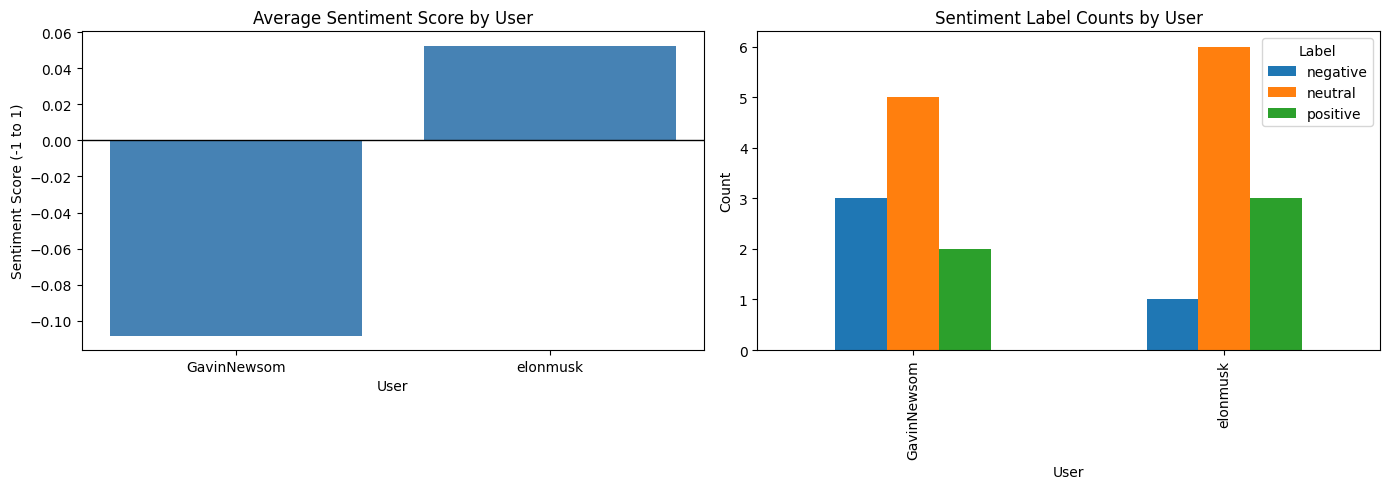

In [5]:
import matplotlib.pyplot as plt

avg_sentiment = df.groupby("username", as_index=False)["sentiment_score"].mean()
label_counts = (
    df.groupby(["username", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(avg_sentiment["username"], avg_sentiment["sentiment_score"], color="steelblue")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Average Sentiment Score by User")
axes[0].set_ylabel("Sentiment Score (-1 to 1)")
axes[0].set_xlabel("User")

label_counts.plot(kind="bar", ax=axes[1])
axes[1].set_title("Sentiment Label Counts by User")
axes[1].set_ylabel("Count")
axes[1].set_xlabel("User")
axes[1].legend(title="Label")

plt.tight_layout()
plt.show()

## Senator's Tweets

In [ ]:
import sys
import subprocess
import pandas as pd

# Fallback dataset loading to handle pyarrow extensions smoothly
try:
    from datasets import load_dataset
    dataset = load_dataset("parquet", data_files="train-00000-of-00001.parquet", split="train")
    train_df = dataset.to_pandas()
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "datasets"])
    from datasets import load_dataset
    dataset = load_dataset("parquet", data_files="train-00000-of-00001.parquet", split="train")
    train_df = dataset.to_pandas()

print(f"Loaded training examples: {train_df.shape[0]} rows x {train_df.shape[1]} columns")
print("Columns:", train_df.columns.tolist())

train_df.head(10)

Loaded training examples: 79754 rows x 7 columns
Columns: ['date', 'id', 'username', 'text', 'party', 'labels', 'embeddings']


,date,id,username,text,party,labels,embeddings
0,2021-10-13 19:47:44,1448374915636383745,SenatorHassan,Happy th birthday to the @USNavy! The strength...,Democrat,1,"[-0.026915843, 0.087234065, 0.018707331, -0.03..."
1,2021-06-30 14:53:13,1410250073003462656,SenatorMenendez,The greatest generation's investment in infras...,Democrat,1,"[0.024044158, -0.0048382296, 0.09699756, -0.03..."
2,2021-08-08 01:11:29,1424176405881966599,SenBillCassidy,"Thanks to @SenTedCruz and @SenatorWarnock, th...",Republican,0,"[-0.002620128, -0.042515174, 0.065084696, 0.01..."
3,2021-04-14 14:02:49,1382333523567185921,SenBlumenthal,/ To get lasting change we cant just lock up t...,Democrat,1,"[-0.045103785, 0.0762336, -0.011798679, -0.044..."
4,2021-12-11 16:06:38,1469700160934621188,SenatorBraun,Today were celebrating years of the Hoosier st...,Republican,0,"[-0.038810886, 0.11611319, 0.06621017, -0.0184..."
5,2021-05-11 17:18:50,1392167324401143812,SenJeffMerkley,The #ForthePeopleAct includes reforms that are...,Democrat,1,"[-0.028889425, -0.04910916, 0.007949473, -0.06..."
6,2021-08-10 16:22:55,1425130548620578816,SenBlumenthal,"Todays strong, bipartisan vote is just the beg...",Democrat,1,"[0.015318287, -0.091730736, 0.029860392, -0.05..."
7,2021-08-12 01:13:26,1425626448518385664,SenatorHagerty,Supporting crime victims requires holding crim...,Republican,0,"[-0.031652693, -0.015171198, 0.028115185, 0.02..."
8,2021-12-11 16:27:51,1469705498224209928,SenBillCassidy,We in Louisiana know how natural disasters cha...,Republican,0,"[-0.019437807, -0.059072897, 0.13377255, -0.01..."
9,2021-01-20 13:55:04,1351890994220957698,CoryBooker,Today we start anew.,Democrat,1,"[-0.044110484, -0.019089103, 0.009209107, 0.03..."


## Text-Only Party Classifier
Train a model using only tweet text to classify each tweet as Democrat or Republican.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

clf_df = train_df[["text", "party"]].dropna().copy()
clf_df["text"] = clf_df["text"].astype(str)

X_train, X_val, y_train, y_val = train_test_split(
    clf_df["text"],
    clf_df["party"],
    test_size=0.2,
    random_state=42,
    stratify=clf_df["party"],
)

text_clf = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(lowercase=True, stop_words="english", ngram_range=(1, 3), min_df=5)),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42, solver="liblinear")),
    ]
)

text_clf.fit(X_train, y_train)
y_pred = text_clf.predict(X_val)

acc = accuracy_score(y_val, y_pred)
print(f"Validation accuracy: {acc:.4f}")
print("\nConfusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_val, y_pred, labels=["Democrat", "Republican"]))
print("\nClassification report:")
print(classification_report(y_val, y_pred, digits=4))

Validation accuracy: 0.8689

Confusion matrix (rows=true, cols=pred):
[[7136 1062]
 [1029 6724]]

Classification report:
              precision    recall  f1-score   support

    Democrat     0.8740    0.8705    0.8722      8198
  Republican     0.8636    0.8673    0.8654      7753

    accuracy                         0.8689     15951
   macro avg     0.8688    0.8689    0.8688     15951
weighted avg     0.8689    0.8689    0.8689     15951



In [8]:
sample_preds = pd.DataFrame({
    "text": X_val.iloc[:10].values,
    "true_party": y_val.iloc[:10].values,
    "pred_party": y_pred[:10],
})
sample_preds

,text,true_party,pred_party
0,House Democrats are panning Sen. RON WYDENs (D...,Republican,Republican
1,"For the first time since early , DHS has a Sen...",Democrat,Democrat
2,Not only is the bipartisan Infrastructure Inve...,Democrat,Democrat
3,The truth you wont hear from the president ton...,Republican,Republican
4,Mayor Gerlach has spent over two decades servi...,Republican,Republican
5,"While in Talkeetna, I met with Israel Mahay, o...",Republican,Republican
6,The steadfast love of the Lord never ceases; H...,Republican,Republican
7,Apparently this guy has to carry a spear to pr...,Democrat,Democrat
8,The #BidenBorderCrisis is putting Texas commun...,Republican,Republican
9,The TRIO program is proven to help students pr...,Democrat,Democrat


In [9]:
misclassified = pd.DataFrame({
    "text": X_val.values,
    "true_party": y_val.values,
    "pred_party": y_pred,
})

misclassified = misclassified[misclassified["true_party"] != misclassified["pred_party"]].copy()
misclassified["text_len"] = misclassified["text"].str.len()

print(f"Misclassified examples: {len(misclassified)}")
misclassified.sample(min(20, len(misclassified)), random_state=42) if len(misclassified) > 0 else misclassified

Misclassified examples: 2091


,text,true_party,pred_party,text_len
14860,The National Right to Work Act ensures all wor...,Republican,Democrat,217
250,Really excited about the amendment I put forwa...,Democrat,Republican,277
1526,El pueblo Colombiano tiene que tener el derech...,Democrat,Republican,266
7166,Today I visited South Central Regional Medical...,Republican,Democrat,302
4228,"Honored to attend tonights #JointAddress, even...",Democrat,Republican,109
12282,UPDATE: Boulder police issued a correction for...,Democrat,Republican,105
9423,America needs a Green Bank - a national financ...,Democrat,Republican,251
396,"Something that is actually demonstrably, laugh...",Democrat,Republican,81
4831,Our @CTNationalGuard and other CT servicememb...,Democrat,Republican,284
4671,"On #WorldCancerDay, were working to advance ca...",Democrat,Republican,127


In [10]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "tfidf__min_df": [2, 5, 10],
    "tfidf__max_df": [0.9, 1.0],
    "model__class_weight": [None, "balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=text_clf,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train)

best_text_clf = grid.best_estimator_
best_pred = best_text_clf.predict(X_val)

print("Best CV score (f1_macro):", round(grid.best_score_, 4))
print("Best params:", grid.best_params_)
print(f"Validation accuracy (best model): {accuracy_score(y_val, best_pred):.4f}")
print("\nValidation classification report (best model):")
print(classification_report(y_val, best_pred, digits=4))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best CV score (f1_macro): 0.8602
Best params: {'model__class_weight': 'balanced', 'tfidf__max_df': 0.9, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2)}
Validation accuracy (best model): 0.8687

Validation classification report (best model):
              precision    recall  f1-score   support

    Democrat     0.8746    0.8690    0.8718      8198
  Republican     0.8624    0.8683    0.8654      7753

    accuracy                         0.8687     15951
   macro avg     0.8685    0.8687    0.8686     15951
weighted avg     0.8687    0.8687    0.8687     15951



## Current Tweets

Train a text-only classifier on historical tweets with `spectrum` target (`C` vs `L`), then predict spectrum on the fetched current posts.

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train/validate directly on the new dataset
CURRENT_POSTS_PATH = "recent_posts_from_ids.csv"
current_df = pd.read_csv(CURRENT_POSTS_PATH)
current_df = current_df.dropna(subset=["text", "spectrum"]).copy()
current_df["text"] = current_df["text"].astype(str)
current_df["spectrum"] = current_df["spectrum"].astype(str).str.strip()

# Keep only known target classes
current_df = current_df[current_df["spectrum"].isin(["C", "L"])].copy()

X_train_s, X_val_s, y_train_s, y_val_s = train_test_split(
    current_df["text"],
    current_df["spectrum"],
    test_size=0.2,
    random_state=42,
    stratify=current_df["spectrum"],
)

spectrum_clf = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(lowercase=True, stop_words="english", ngram_range=(1, 2), min_df=2)),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ]
)

spectrum_clf.fit(X_train_s, y_train_s)
y_val_s_pred = spectrum_clf.predict(X_val_s)

print(f"Validation accuracy (spectrum C/L): {accuracy_score(y_val_s, y_val_s_pred):.4f}")
print("\nConfusion matrix (rows=true, cols=pred) for [C, L]:")
print(confusion_matrix(y_val_s, y_val_s_pred, labels=["C", "L"]))
print("\nClassification report:")
print(classification_report(y_val_s, y_val_s_pred, digits=4))

val_results = pd.DataFrame({
    "text": X_val_s.values,
    "true_spectrum": y_val_s.values,
    "pred_spectrum": y_val_s_pred,
})
val_results["correct"] = val_results["true_spectrum"] == val_results["pred_spectrum"]

print("\nPredicted class counts on validation:")
print(val_results["pred_spectrum"].value_counts())

val_results.head(20)

Validation accuracy (spectrum C/L): 0.7656

Confusion matrix (rows=true, cols=pred) for [C, L]:
[[49 17]
 [13 49]]

Classification report:
              precision    recall  f1-score   support

           C     0.7903    0.7424    0.7656        66
           L     0.7424    0.7903    0.7656        62

    accuracy                         0.7656       128
   macro avg     0.7664    0.7664    0.7656       128
weighted avg     0.7671    0.7656    0.7656       128


Predicted class counts on validation:
pred_spectrum
L    66
C    62
Name: count, dtype: int64


,text,true_spectrum,pred_spectrum,correct
0,"Q: What about the $2,000 checks you promised?\...",L,L,True
1,Donald Trump’s actions in Venezuela do not mak...,L,L,True
2,Chaos spreads like cancer in Minneapolis. What...,C,C,True
3,Bad Bunny was the right choice. Great performa...,L,C,False
4,Jeff Bezos is spending $200 billion on AI and ...,L,C,False
5,His account of Eskimo culture is pretty fascin...,C,C,True
6,Recreational use only. https://t.co/u98huxuUc7,C,C,True
7,"🚨🇨🇳 BREAKING: The Pentagon added, then suddden...",L,L,True
8,Let’s have a little sympathy for the strugglin...,L,L,True
9,🚨I am proud to be on the official Epstein list...,C,C,True


In [12]:
import re
import pandas as pd
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF

CURRENT_POSTS_PATH = "recent_posts_from_ids.csv"
topics_df = pd.read_csv(CURRENT_POSTS_PATH)
topics_df = topics_df.dropna(subset=["text"]).copy()
topics_df["text"] = topics_df["text"].astype(str)

# Remove URLs before vectorization
url_pattern = re.compile(r"https?://\S+|www\.\S+")
topics_df["clean_text"] = topics_df["text"].str.replace(url_pattern, " ", regex=True).str.strip()

print(f"Analyzing {len(topics_df)} tweets for topic trends")

# 1) Most frequent discussion phrases (unigrams/bigrams)
count_vec = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=3000,
    lowercase=True,
)

X_count = count_vec.fit_transform(topics_df["clean_text"])
ngram_counts = X_count.sum(axis=0).A1
ngram_terms = count_vec.get_feature_names_out()

top_n = 25
top_idx = ngram_counts.argsort()[::-1][:top_n]
top_phrases = pd.DataFrame({
    "phrase": ngram_terms[top_idx],
    "count": ngram_counts[top_idx],
})

print("\nTop recurring terms/phrases:")
display(top_phrases)

# 2) Topic modeling (NMF on TF-IDF)
tfidf_vec = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=4000,
    lowercase=True,
)

X_tfidf = tfidf_vec.fit_transform(topics_df["clean_text"])
num_topics = 6
nmf = NMF(n_components=num_topics, random_state=42, init="nndsvda", max_iter=500)
W = nmf.fit_transform(X_tfidf)
H = nmf.components_
terms = tfidf_vec.get_feature_names_out()

topic_keywords = []
for topic_idx, weights in enumerate(H):
    top_term_idx = weights.argsort()[::-1][:8]
    keywords = [terms[i] for i in top_term_idx]
    topic_keywords.append({
        "topic": f"Topic {topic_idx + 1}",
        "keywords": ", ".join(keywords),
    })

topics_summary = pd.DataFrame(topic_keywords)

dominant_topic_idx = W.argmax(axis=1)
topics_df["dominant_topic"] = [f"Topic {idx + 1}" for idx in dominant_topic_idx]
topic_volume = topics_df["dominant_topic"].value_counts().rename_axis("topic").reset_index(name="tweet_count")

print("\nTop discussion topics (NMF keywords):")
display(topics_summary)

print("\nTopic volume (most present topics):")
display(topic_volume)

Analyzing 636 tweets for topic trends

Top recurring terms/phrases:


,phrase,count
0,trump,101
1,just,52
2,epstein,52
3,people,52
4,ice,51
5,new,39
6,today,37
7,files,34
8,breaking,33
9,american,30



Top discussion topics (NMF keywords):


,topic,keywords
0,Topic 1,"trump, donald, donald trump, video, american, ..."
1,Topic 2,"help, lower costs, lower, costs, continue deli..."
2,Topic 3,"bad, bad bunny, bunny, happy, love, day, valen..."
3,Topic 4,"epstein, files, epstein files, bondi, pam bond..."
4,Topic 5,"ice, people, country, new, breaking, amp, just..."
5,Topic 6,"code, code tucker, tucker, use, paid partnersh..."



Topic volume (most present topics):


,topic,tweet_count
0,Topic 5,340
1,Topic 1,125
2,Topic 3,66
3,Topic 4,57
4,Topic 6,25
5,Topic 2,23


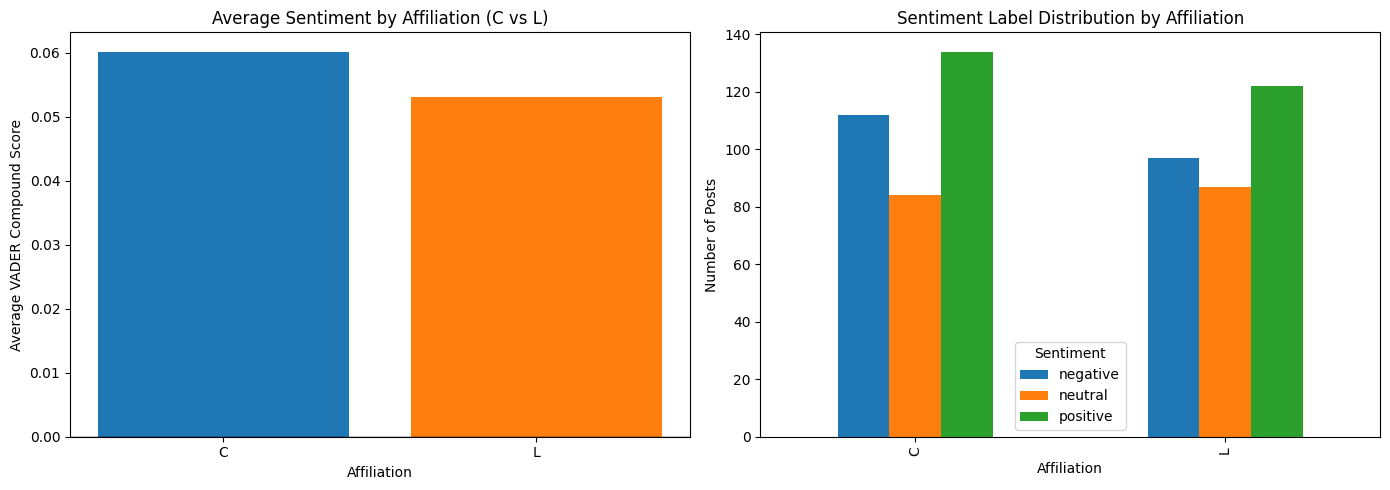

A Welch t-test found no statistically significant difference in mean sentiment between C and L posts (t=0.161, p=0.8722).


,spectrum,sentiment_score
0,C,0.060210
1,L,0.053048


In [14]:
import pandas as pd
import nltk
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from nltk.sentiment import SentimentIntensityAnalyzer

RECENT_POSTS_PATH = "recent_posts_from_ids.csv"

nltk.download("vader_lexicon", quiet=True)
sia_recent = SentimentIntensityAnalyzer()

recent_df = pd.read_csv(RECENT_POSTS_PATH)
recent_df = recent_df.dropna(subset=["text", "spectrum"]).copy()
recent_df["text"] = recent_df["text"].astype(str)
recent_df["spectrum"] = recent_df["spectrum"].astype(str).str.strip()
recent_df = recent_df[recent_df["spectrum"].isin(["C", "L"])].copy()

recent_df["sentiment_score"] = recent_df["text"].apply(
    lambda text: float(sia_recent.polarity_scores(text)["compound"])
)

recent_df["sentiment_label"] = pd.cut(
    recent_df["sentiment_score"],
    bins=[-1.0001, -0.2, 0.2, 1.0001],
    labels=["negative", "neutral", "positive"],
)

sentiment_by_spectrum = (
    recent_df.groupby("spectrum", as_index=False)["sentiment_score"]
    .mean()
    .sort_values("spectrum")
)

label_counts_by_spectrum = (
    recent_df.groupby(["spectrum", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["C", "L"], fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    sentiment_by_spectrum["spectrum"],
    sentiment_by_spectrum["sentiment_score"],
    color=["#1f77b4", "#ff7f0e"],
)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Average Sentiment by Affiliation (C vs L)")
axes[0].set_xlabel("Affiliation")
axes[0].set_ylabel("Average VADER Compound Score")

label_counts_by_spectrum.plot(kind="bar", ax=axes[1])
axes[1].set_title("Sentiment Label Distribution by Affiliation")
axes[1].set_xlabel("Affiliation")
axes[1].set_ylabel("Number of Posts")
axes[1].legend(title="Sentiment")

plt.tight_layout()
plt.show()

c_scores = recent_df.loc[recent_df["spectrum"] == "C", "sentiment_score"]
l_scores = recent_df.loc[recent_df["spectrum"] == "L", "sentiment_score"]
t_stat, p_value = ttest_ind(c_scores, l_scores, equal_var=False, nan_policy="omit")

print(
    f"A Welch t-test found {'a statistically significant' if p_value < 0.05 else 'no statistically significant'} difference in mean sentiment between C and L posts (t={t_stat:.3f}, p={p_value:.4f})."
)

sentiment_by_spectrum

# Model comparison

In [1]:
import sys
import subprocess
import numpy as np
import pandas as pd
import nltk
import torch
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from nltk.sentiment import SentimentIntensityAnalyzer

# Ensure runtime dependencies are available in the notebook kernel
for pkg in ["transformers", "torch", "scikit-learn", "nltk"]:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

from transformers import AutoTokenizer, AutoModelForSequenceClassification

DATA_PATH = "Tweets.csv"
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
SAMPLE_SIZE = 15000
RANDOM_STATE = 42

# Load and clean dataset
tweets_df = pd.read_csv(DATA_PATH).copy()
tweets_df = tweets_df.dropna(subset=["text", "sentiment"]).copy()
tweets_df["text"] = tweets_df["text"].astype(str)
tweets_df["sentiment"] = tweets_df["sentiment"].astype(str).str.strip().str.lower()
tweets_df = tweets_df[tweets_df["sentiment"].isin(["negative", "neutral", "positive"])].copy()

n_total = len(tweets_df)
n_eval = min(SAMPLE_SIZE, n_total)
eval_df = tweets_df.sample(n=n_eval, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Loaded rows with valid labels: {n_total}")
print(f"Evaluating on sample: {n_eval}")

# -------- VADER --------
nltk.download("vader_lexicon", quiet=True)
sia = SentimentIntensityAnalyzer()

def vader_label(score: float) -> str:
    # Standard VADER 3-way thresholds
    if score <= -0.05:
        return "negative"
    if score >= 0.05:
        return "positive"
    return "neutral"

eval_df["vader_score"] = eval_df["text"].apply(lambda t: float(sia.polarity_scores(t)["compound"]))
eval_df["vader_pred"] = eval_df["vader_score"].apply(vader_label)

# -------- RoBERTa --------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.eval()

def normalize_label(label: str) -> str:
    label = str(label).lower()
    if "neg" in label:
        return "negative"
    if "neu" in label:
        return "neutral"
    return "positive"

id2label = {int(k): normalize_label(v) for k, v in model.config.id2label.items()}
weights = torch.tensor([{"negative": -1.0, "neutral": 0.0, "positive": 1.0}[id2label[i]] for i in range(len(id2label))], dtype=torch.float32)

def roberta_batch_predict(texts: list[str], batch_size: int = 32):
    pred_labels = []
    pred_scores = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i : i + batch_size]
            encoded = tokenizer(batch, truncation=True, max_length=512, padding=True, return_tensors="pt")
            logits = model(**encoded).logits
            probs = torch.softmax(logits, dim=-1)

            label_idx = torch.argmax(probs, dim=-1).tolist()
            scores = torch.matmul(probs, weights).tolist()

            pred_labels.extend([id2label[int(idx)] for idx in label_idx])
            pred_scores.extend([float(s) for s in scores])

    return pred_labels, pred_scores

roberta_pred, roberta_score = roberta_batch_predict(eval_df["text"].tolist(), batch_size=32)
eval_df["roberta_pred"] = roberta_pred
eval_df["roberta_score"] = roberta_score

# -------- Performance comparison --------
y_true = eval_df["sentiment"]

vader_acc = accuracy_score(y_true, eval_df["vader_pred"])
vader_f1 = f1_score(y_true, eval_df["vader_pred"], average="macro")

roberta_acc = accuracy_score(y_true, eval_df["roberta_pred"])
roberta_f1 = f1_score(y_true, eval_df["roberta_pred"], average="macro")

print("\n=== Overall Performance on Tweets.csv Sample ===")
print(f"VADER   -> Accuracy: {vader_acc:.4f}, Macro F1: {vader_f1:.4f}")
print(f"RoBERTa -> Accuracy: {roberta_acc:.4f}, Macro F1: {roberta_f1:.4f}")

print("\n=== VADER Classification Report ===")
print(classification_report(y_true, eval_df["vader_pred"], digits=4))

print("=== RoBERTa Classification Report ===")
print(classification_report(y_true, eval_df["roberta_pred"], digits=4))

labels_order = ["negative", "neutral", "positive"]
print("=== VADER Confusion Matrix (rows=true, cols=pred) ===")
print(confusion_matrix(y_true, eval_df["vader_pred"], labels=labels_order))

print("\n=== RoBERTa Confusion Matrix (rows=true, cols=pred) ===")
print(confusion_matrix(y_true, eval_df["roberta_pred"], labels=labels_order))

# Optional score-space agreement between models
pearson_corr = pearsonr(eval_df["vader_score"], eval_df["roberta_score"])[0]
spearman_corr = spearmanr(eval_df["vader_score"], eval_df["roberta_score"]).correlation
print(f"\nVADER vs RoBERTa score correlation -> Pearson: {pearson_corr:.4f}, Spearman: {spearman_corr:.4f}")

eval_df[["text", "sentiment", "vader_pred", "roberta_pred", "vader_score", "roberta_score"]].head(20)

/home/max/X-Signal/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded rows with valid labels: 27480
Evaluating on sample: 15000


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 10692.97it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== Overall Performance on Tweets.csv Sample ===
VADER   -> Accuracy: 0.6305, Macro F1: 0.6280
RoBERTa -> Accuracy: 0.7078, Macro F1: 0.7070

=== VADER Classification Report ===
              precision    recall  f1-score   support

    negative     0.6968    0.5922    0.6402      4237
     neutral     0.6989    0.4708    0.5626      6045
    positive     0.5600    0.8696    0.6813      4718

    accuracy                         0.6305     15000
   macro avg     0.6519    0.6442    0.6280     15000
weighted avg     0.6546    0.6305    0.6219     15000

=== RoBERTa Classification Report ===
              precision    recall  f1-score   support

    negative     0.6890    0.8015    0.7410      4237
     neutral     0.7686    0.5045    0.6092      6045
    positive     0.6834    0.8841    0.7709      4718

    accuracy                         0.7078     15000
   macro avg     0.7137    0.7300    0.7070     15000
weighted avg     0.7193    0.7078    0.6973     15000

=== VADER Confusion M

,text,sentiment,vader_pred,roberta_pred,vader_score,roberta_score
0,Enjoy! Family trumps everything,positive,positive,positive,0.5411,0.918773
1,--of them kinda turns me off of it all. And ...,negative,neutral,negative,0.0000,-0.866201
2,Clive it`s my birthday pat me http://apps.fac...,neutral,neutral,positive,0.0000,0.835312
3,congrats hey,positive,positive,positive,0.5267,0.968200
4,is texting,neutral,neutral,neutral,0.0000,0.021128
5,Do you have any idea when the (not so) patien...,neutral,negative,neutral,-0.2500,0.101486
6,Tell him where...,neutral,neutral,neutral,0.0000,0.025780
7,"Ooooh, I`m jealous I might try and get some ...",negative,negative,negative,-0.7750,-0.874744
8,OHSHNAPSSS. is she pissed at blair as usual ?...,neutral,negative,neutral,-0.6369,-0.116537
9,wee. done with advance audit paper,neutral,neutral,neutral,0.0000,0.337774


In [6]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

rows_to_show = 50
offset = 10
print(f"Showing rows {offset} to {offset + rows_to_show - 1} with full tweet text")
tweets_df[["textID", "text", "sentiment"]].iloc[offset:offset + rows_to_show]

Showing rows 10 to 59 with full tweet text


,textID,text,sentiment
10,2339a9b08b,"as much as i love to be hopeful, i reckon the chances are minimal =P i`m never gonna get my cake and stuff",neutral
11,16fab9f95b,I really really like the song Love Story by Taylor Swift,positive
12,74a76f6e0a,My Sharpie is running DANGERously low on ink,negative
13,04dd1d2e34,i want to go to music tonight but i lost my voice.,negative
14,bbe3cbf620,test test from the LG enV2,neutral
15,8a939bfb59,"Uh oh, I am sunburned",negative
16,3440297f8b,"S`ok, trying to plot alternatives as we speak *sigh*",negative
17,919fa93391,"i`ve been sick for the past few days and thus, my hair looks wierd. if i didnt have a hat on it would look... http://tinyurl.com/mnf4kw",negative
18,af3fed7fc3,is back home now gonna miss every one,negative
19,40e7becabf,Hes just not that into you,neutral


In [5]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

rows_to_show = 50
print(f"Showing first {rows_to_show} rows from eval_df with full tweet text")
eval_df[["text", "sentiment", "vader_pred", "roberta_pred", "vader_score", "roberta_score"]].head(rows_to_show)

Showing first 50 rows from eval_df with full tweet text


,text,sentiment,vader_pred,roberta_pred,vader_score,roberta_score
0,Enjoy! Family trumps everything,positive,positive,positive,0.5411,0.918773
1,"--of them kinda turns me off of it all. And then I buy more of them and dig a deeper hole, etc. ;;",negative,neutral,negative,0.0000,-0.866201
2,Clive it`s my birthday pat me http://apps.facebook.com/dogbook/profile/view/6386106,neutral,neutral,positive,0.0000,0.835312
3,congrats hey,positive,positive,positive,0.5267,0.968200
4,is texting,neutral,neutral,neutral,0.0000,0.021128
5,Do you have any idea when the (not so) patient fans will see some teaser pics of you all in costume?,neutral,negative,neutral,-0.2500,0.101486
6,Tell him where...,neutral,neutral,neutral,0.0000,0.025780
7,"Ooooh, I`m jealous I might try and get some for the saturday but I have an exam on the monday that Im gonna fail",negative,negative,negative,-0.7750,-0.874744
8,"OHSHNAPSSS. is she pissed at blair as usual ? hahah. & yeeeah, i bake cookies",neutral,negative,neutral,-0.6369,-0.116537
9,wee. done with advance audit paper,neutral,neutral,neutral,0.0000,0.337774


In [4]:
import sys
import subprocess
import glob
import pandas as pd
import numpy as np
import torch
import nltk
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from nltk.sentiment import SentimentIntensityAnalyzer

# Ensure transformers and datasets are installed
for pkg in ["transformers", "torch", "datasets", "pyarrow"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset

PREFERRED_PARQUET_PATHS = [
    "train-00000-of-00001.parquet",
    "test-00000-of-00001.parquet",
]
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
SAMPLE_SIZE = 7000
RANDOM_STATE = 42
LABEL_MAP = {0: "negative", 1: "neutral", 2: "positive"}

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    normalized = {col: str(col).strip().lower() for col in df.columns}
    # Keep first occurrence if duplicates arise after normalization
    dedup = {}
    for original, norm in normalized.items():
        if norm not in dedup:
            dedup[original] = norm
    return df.rename(columns=dedup)

def load_parquet_candidates(paths: list[str]) -> list[tuple[str, pd.DataFrame]]:
    existing = []
    for p in paths:
        if p in glob.glob("*.parquet") and p not in existing:
            existing.append(p)
    for p in sorted(glob.glob("*.parquet")):
        if p not in existing:
            existing.append(p)

    loaded = []
    for p in existing:
        try:
            loaded.append((p, pd.read_parquet(p)))
        except Exception as e:
            print(f"Skipping {p}: {e}")
    return loaded

# Load parquet and prefer a file that contains text + label
candidates = load_parquet_candidates(PREFERRED_PARQUET_PATHS)
if not candidates:
    print("NO_PARQUET_FOUND")
    raise SystemExit(0)

selected_path = None
parquet_df = None

for p, candidate_df in candidates:
    candidate_df = normalize_columns(candidate_df)
    cols = set(candidate_df.columns)
    if {"text", "label"}.issubset(cols):
        selected_path = p
        parquet_df = candidate_df
        break

if parquet_df is None:
    # Fallback: first parquet with text + sentiment, else first parquet
    for p, candidate_df in candidates:
        candidate_df = normalize_columns(candidate_df)
        cols = set(candidate_df.columns)
        if {"text", "sentiment"}.issubset(cols):
            selected_path = p
            parquet_df = candidate_df
            break

if parquet_df is None:
    selected_path, parquet_df = candidates[0]
    parquet_df = normalize_columns(parquet_df)

print(f"Using parquet file: {selected_path}")
print(f"Columns (normalized): {list(parquet_df.columns)}")

parquet_df = parquet_df.dropna(subset=["text"]).copy()
parquet_df["text"] = parquet_df["text"].astype(str)

# Resolve ground truth labels to string classes expected by reports
if "label" in parquet_df.columns:
    parquet_df["label"] = pd.to_numeric(parquet_df["label"], errors="coerce").astype("Int64")
    parquet_df = parquet_df[parquet_df["label"].isin(LABEL_MAP.keys())].copy()
    parquet_df["target_label"] = parquet_df["label"].map(LABEL_MAP)
    target_source = "label"
elif "sentiment" in parquet_df.columns:
    parquet_df["sentiment"] = parquet_df["sentiment"].astype(str).str.strip().str.lower()
    parquet_df = parquet_df[parquet_df["sentiment"].isin(LABEL_MAP.values())].copy()
    parquet_df["target_label"] = parquet_df["sentiment"]
    target_source = "sentiment"
else:
    parquet_df["target_label"] = pd.NA
    target_source = None

n_total = len(parquet_df)
n_eval = min(SAMPLE_SIZE, n_total)
eval_df = parquet_df.sample(n=n_eval, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Loaded rows: {n_total}")
print(f"Evaluating on sample: {n_eval}")
if target_source == "label":
    print("Ground truth source: label (0=negative, 1=neutral, 2=positive)")
elif target_source == "sentiment":
    print("Ground truth source: sentiment")
else:
    print("Ground truth source: not found")

# -------- VADER --------
nltk.download("vader_lexicon", quiet=True)
sia = SentimentIntensityAnalyzer()

def vader_label(score: float) -> str:
    if score <= -0.05:
        return "negative"
    if score >= 0.05:
        return "positive"
    return "neutral"

eval_df["vader_score"] = eval_df["text"].apply(lambda t: float(sia.polarity_scores(t)["compound"]))
eval_df["vader_pred"] = eval_df["vader_score"].apply(vader_label)

# -------- RoBERTa --------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.eval()

def normalize_label(label: str) -> str:
    label = str(label).lower()
    if "neg" in label:
        return "negative"
    if "neu" in label:
        return "neutral"
    return "positive"

id2label = {int(k): normalize_label(v) for k, v in model.config.id2label.items()}
weights = torch.tensor([{"negative": -1.0, "neutral": 0.0, "positive": 1.0}[id2label[i]] for i in range(len(id2label))], dtype=torch.float32)

def roberta_batch_predict(texts: list[str], batch_size: int = 32):
    pred_labels = []
    pred_scores = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i : i + batch_size]
            encoded = tokenizer(batch, truncation=True, max_length=512, padding=True, return_tensors="pt")
            logits = model(**encoded).logits
            probs = torch.softmax(logits, dim=-1)

            label_idx = torch.argmax(probs, dim=-1).tolist()
            scores = torch.matmul(probs, weights).tolist()

            pred_labels.extend([id2label[int(idx)] for idx in label_idx])
            pred_scores.extend([float(s) for s in scores])

    return pred_labels, pred_scores

roberta_pred, roberta_score = roberta_batch_predict(eval_df["text"].tolist(), batch_size=32)
eval_df["roberta_pred"] = roberta_pred
eval_df["roberta_score"] = roberta_score

# -------- Performance comparison --------
if target_source is not None and eval_df["target_label"].notna().all():
    y_true = eval_df["target_label"]

    vader_acc = accuracy_score(y_true, eval_df["vader_pred"])
    vader_f1 = f1_score(y_true, eval_df["vader_pred"], average="macro")

    roberta_acc = accuracy_score(y_true, eval_df["roberta_pred"])
    roberta_f1 = f1_score(y_true, eval_df["roberta_pred"], average="macro")

    print("\n=== Accuracy Report by Model ===")
    print(f"VADER   -> Accuracy: {vader_acc:.4f}, Macro F1: {vader_f1:.4f}")
    print(f"RoBERTa -> Accuracy: {roberta_acc:.4f}, Macro F1: {roberta_f1:.4f}")

    labels_order = ["negative", "neutral", "positive"]
    print("\n=== VADER Classification Report ===")
    print(classification_report(y_true, eval_df["vader_pred"], digits=4))
    print("=== RoBERTa Classification Report ===")
    print(classification_report(y_true, eval_df["roberta_pred"], digits=4))

    print("=== VADER Confusion Matrix (rows=true, cols=pred) ===")
    print(confusion_matrix(y_true, eval_df["vader_pred"], labels=labels_order))
    print("\n=== RoBERTa Confusion Matrix (rows=true, cols=pred) ===")
    print(confusion_matrix(y_true, eval_df["roberta_pred"], labels=labels_order))
else:
    print("\nNo ground-truth label/sentiment column found; skipping per-model accuracy report.")

# Inter-model agreement and score correlation
eval_df["label_match"] = eval_df["vader_pred"] == eval_df["roberta_pred"]
agreement = eval_df["label_match"].mean()
pearson_corr = pearsonr(eval_df["vader_score"], eval_df["roberta_score"])[0]
spearman_corr = spearmanr(eval_df["vader_score"], eval_df["roberta_score"]).correlation

print(f"\nLabel agreement (VADER vs RoBERTa): {agreement:.2%}")
print(f"Pearson correlation (scores): {pearson_corr:.4f}")
print(f"Spearman correlation (scores): {spearman_corr:.4f}")

labels_order = ["negative", "neutral", "positive"]
print("\n=== Confusion Matrix (rows=VADER, cols=RoBERTa) ===")
print(confusion_matrix(eval_df["vader_pred"], eval_df["roberta_pred"], labels=labels_order))

preview_cols = ["text", "vader_pred", "roberta_pred", "vader_score", "roberta_score"]
if "target_label" in eval_df.columns and eval_df["target_label"].notna().all():
    preview_cols.insert(1, "target_label")

eval_df[preview_cols].head(20)

Using parquet file: test-00000-of-00001.parquet
Columns (normalized): ['text', 'label']
Loaded rows: 12284
Evaluating on sample: 7000
Ground truth source: label (0=negative, 1=neutral, 2=positive)


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8173.26it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== Accuracy Report by Model ===
VADER   -> Accuracy: 0.5234, Macro F1: 0.5198
RoBERTa -> Accuracy: 0.7246, Macro F1: 0.7246

=== VADER Classification Report ===
              precision    recall  f1-score   support

    negative     0.6003    0.5480    0.5729      2283
     neutral     0.6515    0.4536    0.5348      3371
    positive     0.3441    0.6568    0.4516      1346

    accuracy                         0.5234      7000
   macro avg     0.5320    0.5528    0.5198      7000
weighted avg     0.5757    0.5234    0.5312      7000

=== RoBERTa Classification Report ===
              precision    recall  f1-score   support

    negative     0.6995    0.8208    0.7553      2283
     neutral     0.7588    0.6589    0.7053      3371
    positive     0.7009    0.7259    0.7131      1346

    accuracy                         0.7246      7000
   macro avg     0.7197    0.7352    0.7246      7000
weighted avg     0.7283    0.7246    0.7231      7000

=== VADER Confusion Matrix (rows=true

,text,target_label,vader_pred,roberta_pred,vader_score,roberta_score
0,Do you think Michelle Obama wanted to smack Me...,neutral,neutral,neutral,0.0000,-0.267726
1,Well that finale was one big mindfuck 😳 #Westw...,neutral,positive,negative,0.2732,-0.788949
2,"Luis Enrique: ""In the first half I can't remem...",neutral,positive,neutral,0.5574,0.123449
3,Happy Thanksgiving from a couple of bad hombre...,positive,positive,positive,0.1260,0.272929
4,@user Viper. Another fucking nazi,negative,neutral,negative,0.0000,-0.918231
5,Viendo The Walking Dead 7x02 - El pozo #TheWal...,neutral,negative,neutral,-0.6486,0.085140
6,Watch peanut butter drone strikes that could s...,neutral,positive,neutral,0.1779,0.423561
7,Wow! Liberals are now asking for a refund from...,negative,positive,neutral,0.7840,-0.184411
8,#NBA @user #Nuggets - @user #Jazz Highligts,neutral,neutral,neutral,0.0000,0.027789
9,#NationalFastFoodDay Would love to live there....,positive,positive,positive,0.6369,0.982946


In [3]:
import glob
import pandas as pd

preferred = [
    'test-00000-of-00001.parquet',
]
files = [f for f in preferred if f in glob.glob('*.parquet')]
if not files:
    files = sorted(glob.glob('*.parquet'))

if not files:
    print('NO_PARQUET_FOUND')
    raise SystemExit(0)

path = files[0]
print(f'\nUsing parquet file: {path}')
df = pd.read_parquet(path)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print('\nHead (first 5 rows):')
print(df.head(5).to_string(index=False))


Using parquet file: test-00000-of-00001.parquet
Shape: (12284, 2)
Columns: ['text', 'label']

Head (first 5 rows):
                                                                                                                                 text  label
                                     @user @user what do these '1/2 naked pics' have to do with anything? They're not even like that.      1
                                                             OH: “I had a blue penis while I was this” [playing with Google Earth VR]      1
                                              @user @user That's coming, but I think the victims are going to be Medicaid recipients.      1
                                                  I think I may be finally in with the in crowd #mannequinchallenge  #grads2014 @user      2
@user Wow,first Hugo Chavez and now Fidel Castro. Danny Glover, Michael Moore, Oliver Stone, and Sean Penn are running out of heroes.      0


$$
\text{sentiment\_label}(\text{score}) = 
\begin{cases} 
  \text{negative} & \text{if } \text{score} \le -0.2 \\ 
  \text{neutral} & \text{if } -0.2 < \text{score} < 0.2 \\ 
  \text{positive} & \text{if } \text{score} \ge 0.2 
\end{cases}
$$